In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

In [4]:
df = pd.read_csv('titanic_data_updated.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S


In [7]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [8]:
x = df.drop(['Survived'], axis=1)
y = df['Survived']

x, y

(     Pclass     Sex   Age  SibSp  Parch     Fare Cabin Embarked
 0     third    male  22.0      1      0   7.2500   NaN        S
 1     first  female  38.0      1      0  71.2833   C85        C
 2     third  female  26.0      0      0   7.9250   NaN        S
 3     first  female  35.0      1      0  53.1000  C123        S
 4     third    male  35.0      0      0   8.0500   NaN        S
 ..      ...     ...   ...    ...    ...      ...   ...      ...
 886  second    male  27.0      0      0  13.0000   NaN        S
 887   first  female  19.0      0      0  30.0000   B42        S
 888   third  female   NaN      1      2  23.4500   NaN        S
 889   first    male  26.0      0      0  30.0000  C148        C
 890   third    male  32.0      0      0   7.7500   NaN        Q
 
 [891 rows x 8 columns],
 0       no
 1      yes
 2      yes
 3      yes
 4       no
       ... 
 886     no
 887    yes
 888     no
 889    yes
 890     no
 Name: Survived, Length: 891, dtype: object)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S
270,first,male,NaN,0,0,31.0000,NaN,S
860,third,male,41.0,2,0,14.1083,NaN,S
435,first,female,14.0,1,2,120.0000,B96 B98,S


In [11]:
y_train

,Survived
331,no
733,no
382,no
704,no
813,no
...,...
106,yes
270,no
860,no
435,yes


In [12]:
x_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,140
SibSp,0
Parch,0
Fare,0
Cabin,553
Embarked,2


In [13]:
x_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,37
SibSp,0
Parch,0
Fare,0
Cabin,134
Embarked,0


# missing value handle using Pandas



In [14]:
# fill "missing" in cabin nan value with pandas
x_train['Cabin'] = x_train['Cabin'].fillna("Missing")
x_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,140
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,2


In [15]:
x_test['Cabin'] = x_test['Cabin'].fillna("Missing")
x_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,37
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0


In [16]:
# mean impute
age_mean = x_train['Age'].mean()

x_train['age_mean_imputer'] = x_train['Age'].fillna(age_mean)

x_test['age_mean_imputer'] = x_test['Age'].fillna(age_mean)

print(x_train)
print(x_test)


     Pclass     Sex   Age  SibSp  Parch      Fare    Cabin Embarked  \
331   first    male  45.5      0      0   28.5000     C124        S   
733  second    male  23.0      0      0   13.0000  Missing        S   
382   third    male  32.0      0      0    7.9250  Missing        S   
704   third    male  26.0      1      0    7.8542  Missing        S   
813   third  female   6.0      4      2   31.2750  Missing        S   
..      ...     ...   ...    ...    ...       ...      ...      ...   
106   third  female  21.0      0      0    7.6500  Missing        S   
270   first    male   NaN      0      0   31.0000  Missing        S   
860   third    male  41.0      2      0   14.1083  Missing        S   
435   first  female  14.0      1      2  120.0000  B96 B98        S   
102   first    male  21.0      0      1   77.2875      D26        S   

     age_mean_imputer  
331         45.500000  
733         23.000000  
382         32.000000  
704         26.000000  
813          6.000000  
.. 

In [17]:
# median impute
age_median = x_train['Age'].median()

x_train['age_median_imputer'] = x_train['Age'].fillna(age_median)

x_test['age_median_imputer'] = x_test['Age'].fillna(age_median)


<Axes: xlabel='Age', ylabel='Density'>

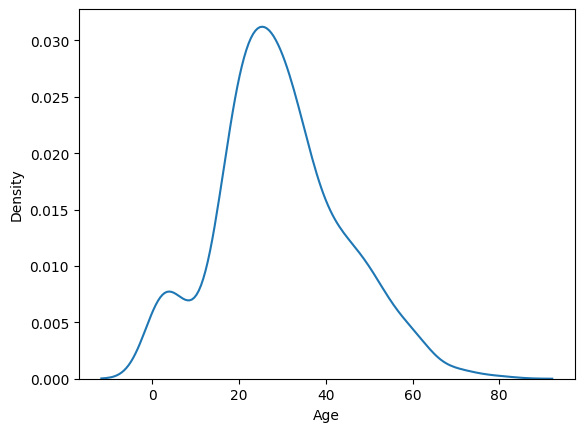

In [18]:
sns.kdeplot(data=x_train, x='Age')

<Axes: xlabel='age_mean_imputer', ylabel='Density'>

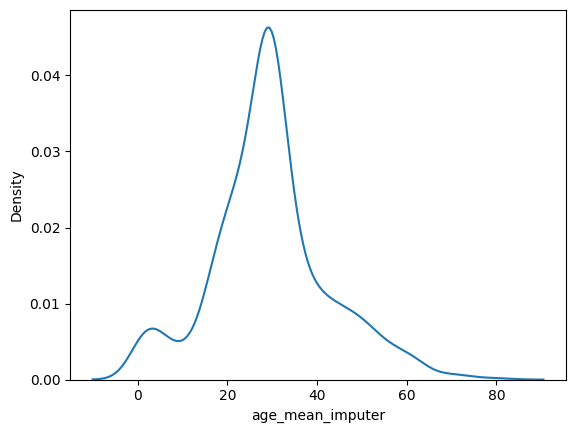

In [19]:
sns.kdeplot(data=x_train, x='age_mean_imputer')

<Axes: xlabel='age_median_imputer', ylabel='Density'>

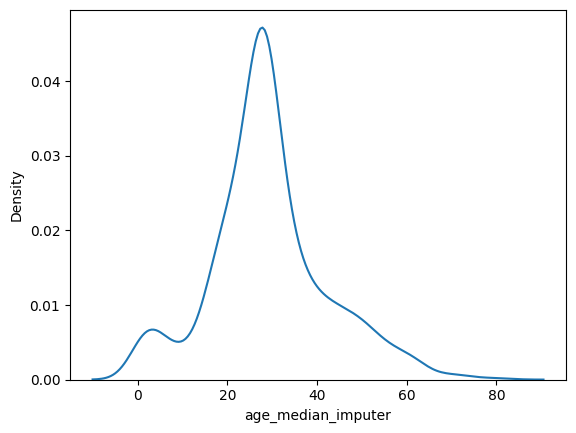

In [20]:
sns.kdeplot(data=x_train, x='age_median_imputer')

# missing value handle using simple imputer


In [21]:
from sklearn.impute import SimpleImputer

age_mean = x_train['Age'].mean()
age_median = x_train['Age'].median()

age_imputor = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputor.fit(x_train[['Age']])

x_train['Age'] = age_imputor.transform(x_train[['Age']]).ravel()

In [22]:
x_train.isnull().sum()
x_train.drop(['age_mean_imputer', 'age_median_imputer'], axis=1, inplace=True)

In [23]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.500000,0,0,28.5000,C124,S
733,second,male,23.000000,0,0,13.0000,Missing,S
382,third,male,32.000000,0,0,7.9250,Missing,S
704,third,male,26.000000,1,0,7.8542,Missing,S
813,third,female,6.000000,4,2,31.2750,Missing,S
...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S
270,first,male,29.498846,0,0,31.0000,Missing,S
860,third,male,41.000000,2,0,14.1083,Missing,S
435,first,female,14.000000,1,2,120.0000,B96 B98,S


In [24]:
x_test['Age'] = age_imputor.transform(x_test[['Age']])
x_test.isnull().sum()


,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
age_mean_imputer,0
age_median_imputer,0


In [25]:
x_test.drop(['age_mean_imputer', 'age_median_imputer'], axis=1, inplace=True)

In [26]:
x_test.isnull().sum()


,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0


In [27]:
x_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,2


In [28]:
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

embarked_imputer.fit(x_train[['Embarked']])

x_train['Embarked'] = embarked_imputer.transform(x_train[['Embarked']]).ravel()


In [29]:
x_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0


In [30]:
x_test.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0


# Outlier Detections

## Using Z-Score

In [31]:
mean_of_age = x_train['Age'].mean()
std_of_age = x_train['Age'].std()

x_train["zScore_age"]= (x_train['Age'] - mean_of_age)/ std_of_age

x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,zScore_age
331,first,male,45.500000,0,0,28.5000,C124,S,1.231398e+00
733,second,male,23.000000,0,0,13.0000,Missing,S,-5.001304e-01
382,third,male,32.000000,0,0,7.9250,Missing,S,1.924808e-01
704,third,male,26.000000,1,0,7.8542,Missing,S,-2.692600e-01
813,third,female,6.000000,4,2,31.2750,Missing,S,-1.808396e+00
...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,-6.540440e-01
270,first,male,29.498846,0,0,31.0000,Missing,S,2.734055e-16
860,third,male,41.000000,2,0,14.1083,Missing,S,8.850920e-01
435,first,female,14.000000,1,2,120.0000,B96 B98,S,-1.192742e+00


In [32]:
outliers_age = x_train[x_train['zScore_age'] > 3]

print(len(outliers_age))
display(outliers_age)

5


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,zScore_age
116,third,male,70.5,0,0,7.750,Missing,Q,3.155317
745,first,male,70.0,1,1,71.000,B22,S,3.116839
630,first,male,80.0,0,0,30.000,A23,S,3.886407
851,third,male,74.0,0,0,7.775,Missing,S,3.424666
672,second,male,70.0,0,0,10.500,Missing,S,3.116839


In [33]:
mean_of_fare = x_train['Fare'].mean()
std_of_fare = x_train['Fare'].std()

x_train["zScore_fare"]= (x_train['Fare'] - mean_of_fare)/ std_of_fare

x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,zScore_age,zScore_fare
331,first,male,45.500000,0,0,28.5000,C124,S,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,-1.192742e+00,1.682019


In [34]:
outliers_fare = x_train[x_train['zScore_fare'] > 3]

print(len(outliers_fare))
display(outliers_fare)

17


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,zScore_age,zScore_fare
118,first,male,24.000000,0,1,247.5208,B58 B60,C,-4.231736e-01,4.135780
716,first,female,38.000000,0,0,227.5250,C45,C,6.542216e-01,3.751020
377,first,male,27.000000,0,2,211.5000,C82,C,-1.923032e-01,3.442666
742,first,female,21.000000,2,2,262.3750,B57 B59 B63 B66,C,-6.540440e-01,4.421605
380,first,female,42.000000,0,0,227.5250,Missing,C,9.620488e-01,3.751020
779,first,female,43.000000,0,1,211.3375,B3,S,1.039006e+00,3.439539
730,first,female,29.000000,0,0,211.3375,B5,S,-3.838960e-02,3.439539
88,first,female,23.000000,3,2,263.0000,C23 C25 C27,S,-5.001304e-01,4.433631
341,first,female,24.000000,3,2,263.0000,C23 C25 C27,S,-4.231736e-01,4.433631
557,first,male,29.498846,0,0,227.5250,Missing,C,2.734055e-16,3.751020


## Outliers with IQR

In [35]:
# age

age_q1 = x_train['Age'].quantile(0.25)

age_q3 = x_train['Age'].quantile(0.75)

age_IQR = age_q3 - age_q1

age_minimum = age_q1 - 1.5 * age_IQR

age_maximum = age_q3 + 1.5 * age_IQR


print(age_minimum, age_maximum)

2.5 54.5


In [36]:
age_outlier_IQR = x_train[(x_train['Age'] < age_minimum) | (x_train['Age'] > age_maximum)]

print(len(age_outlier_IQR))
display(age_outlier_IQR)

54


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,zScore_age,zScore_fare
326,third,male,61.00,0,0,6.2375,Missing,S,2.424228,-0.507004
483,third,female,63.00,0,0,9.5875,Missing,S,2.578141,-0.442543
7,third,male,2.00,3,1,21.0750,Missing,S,-2.116223,-0.221500
305,first,male,0.92,1,2,151.5500,C22 C26,S,-2.199336,2.289105
829,first,female,62.00,0,0,80.0000,B28,S,2.501185,0.912337
626,second,male,57.00,0,0,12.3500,Missing,Q,2.116401,-0.389387
456,first,male,65.00,0,0,26.5500,E38,S,2.732055,-0.116150
172,third,female,1.00,1,1,11.1333,Missing,S,-2.193180,-0.412799
164,third,male,1.00,4,1,39.6875,Missing,S,-2.193180,0.136642
381,third,female,1.00,0,2,15.7417,Missing,C,-2.193180,-0.324124


In [37]:
# fare

fare_q1 = x_train['Fare'].quantile(0.25)

fare_q3 = x_train['Fare'].quantile(0.75)

fare_IQR = fare_q3 - fare_q1

fare_minimum = fare_q1 - 1.5 * fare_IQR

fare_maximum = fare_q3 + 1.5 * fare_IQR


print(fare_minimum, fare_maximum)

-25.937499999999996 64.3625


In [38]:
fare_outlier_IQR = x_train[(x_train['Fare'] < fare_minimum) | (x_train['Fare'] > fare_maximum)]

print(len(fare_outlier_IQR))
display(fare_outlier_IQR)

96


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,zScore_age,zScore_fare
118,first,male,24.0,0,1,247.5208,B58 B60,C,-0.423174,4.135780
486,first,female,35.0,1,0,90.0000,C93,S,0.423351,1.104757
716,first,female,38.0,0,0,227.5250,C45,C,0.654222,3.751020
390,first,male,36.0,1,2,120.0000,B96 B98,S,0.500308,1.682019
377,first,male,27.0,0,2,211.5000,C82,C,-0.192303,3.442666
...,...,...,...,...,...,...,...,...,...,...
681,first,male,27.0,0,0,76.7292,D49,C,-0.192303,0.849400
385,second,male,18.0,0,0,73.5000,Missing,S,-0.884914,0.787264
700,first,female,18.0,1,0,227.5250,C62 C64,C,-0.884914,3.751020
435,first,female,14.0,1,2,120.0000,B96 B98,S,-1.192742,1.682019


### Z score is better for age features in outlier detection

### IQR is better for fare features in outlier detection

In [39]:
## Z score is better for age features in outlier detection

x_train = x_train[abs(x_train['zScore_age']) <= 3]
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,zScore_age,zScore_fare
331,first,male,45.500000,0,0,28.5000,C124,S,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,-1.192742e+00,1.682019


In [40]:
### IQR is better for fare features in outlier detection

x_train = x_train[(x_train['Fare'] > fare_minimum) & (x_train['Fare'] < fare_maximum)]
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,zScore_age,zScore_fare
331,first,male,45.500000,0,0,28.5000,C124,S,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...
20,second,male,35.000000,0,0,26.0000,Missing,S,4.233512e-01,-0.126733
71,third,female,16.000000,5,2,46.9000,Missing,S,-1.038828e+00,0.275425
106,third,female,21.000000,0,0,7.6500,Missing,S,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,2.734055e-16,-0.030523


# Encoding
## 1. ordinal encoding
## 2. one Hot encoding
## 3. label encoding

In [41]:
# 1. Ordinal encoding

from sklearn.preprocessing import OrdinalEncoder

pclass_encoder = OrdinalEncoder(categories=[["third", "second", "first"]])

pclass_encoder.fit(x_train[['Pclass']])

x_train['encoded_Pclass'] = pclass_encoder.transform(x_train[['Pclass']]).ravel()
x_test['encoded_Pclass'] = pclass_encoder.transform(x_test[['Pclass']]).ravel()


x_train

/tmp/ipykernel_10374/2194877339.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train['encoded_Pclass'] = pclass_encoder.transform(x_train[['Pclass']]).ravel()


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,zScore_age,zScore_fare,encoded_Pclass
331,first,male,45.500000,0,0,28.5000,C124,S,1.231398e+00,-0.078628,2.0
733,second,male,23.000000,0,0,13.0000,Missing,S,-5.001304e-01,-0.376880,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,1.924808e-01,-0.474533,0.0
704,third,male,26.000000,1,0,7.8542,Missing,S,-2.692600e-01,-0.475896,0.0
813,third,female,6.000000,4,2,31.2750,Missing,S,-1.808396e+00,-0.025232,0.0
...,...,...,...,...,...,...,...,...,...,...,...
20,second,male,35.000000,0,0,26.0000,Missing,S,4.233512e-01,-0.126733,1.0
71,third,female,16.000000,5,2,46.9000,Missing,S,-1.038828e+00,0.275425,0.0
106,third,female,21.000000,0,0,7.6500,Missing,S,-6.540440e-01,-0.479825,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,2.734055e-16,-0.030523,2.0


In [42]:
x_train.drop(['zScore_age', 'zScore_fare'], axis=1, inplace=True)
x_train

/tmp/ipykernel_10374/3990052890.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train.drop(['zScore_age', 'zScore_fare'], axis=1, inplace=True)


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,encoded_Pclass
331,first,male,45.500000,0,0,28.5000,C124,S,2.0
733,second,male,23.000000,0,0,13.0000,Missing,S,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,0.0
704,third,male,26.000000,1,0,7.8542,Missing,S,0.0
813,third,female,6.000000,4,2,31.2750,Missing,S,0.0
...,...,...,...,...,...,...,...,...,...
20,second,male,35.000000,0,0,26.0000,Missing,S,1.0
71,third,female,16.000000,5,2,46.9000,Missing,S,0.0
106,third,female,21.000000,0,0,7.6500,Missing,S,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,2.0


In [43]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,encoded_Pclass
709,third,male,29.498846,1,1,15.2458,Missing,C,0.0
439,second,male,31.000000,0,0,10.5000,Missing,S,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,0.0
720,second,female,6.000000,0,1,33.0000,Missing,S,1.0
39,third,female,14.000000,1,0,11.2417,Missing,C,0.0
...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,0.0
773,third,male,29.498846,0,0,7.2250,Missing,C,0.0
25,third,female,38.000000,1,5,31.3875,Missing,S,0.0
84,second,female,17.000000,0,0,10.5000,Missing,S,1.0


In [44]:
# 2. One hot encoding
from sklearn.preprocessing import OneHotEncoder

sex_ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

sex_ohe.fit(x_train[['Sex']])

encoded_df = sex_ohe.transform(x_train[['Sex']])

x_train = pd.concat([x_train, encoded_df], axis=1)

x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,encoded_Pclass,Sex_female,Sex_male
331,first,male,45.500000,0,0,28.5000,C124,S,2.0,0.0,1.0
733,second,male,23.000000,0,0,13.0000,Missing,S,1.0,0.0,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,0.0,0.0,1.0
704,third,male,26.000000,1,0,7.8542,Missing,S,0.0,0.0,1.0
813,third,female,6.000000,4,2,31.2750,Missing,S,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
20,second,male,35.000000,0,0,26.0000,Missing,S,1.0,0.0,1.0
71,third,female,16.000000,5,2,46.9000,Missing,S,0.0,1.0,0.0
106,third,female,21.000000,0,0,7.6500,Missing,S,0.0,1.0,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,2.0,0.0,1.0


In [45]:
embarked_ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

embarked_ohe.fit(x_train[['Embarked']])

encoded_df = embarked_ohe.transform(x_train[['Embarked']])

x_train = pd.concat([x_train, encoded_df], axis=1)

x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,first,male,45.500000,0,0,28.5000,C124,S,2.0,0.0,1.0,0.0,0.0,1.0
733,second,male,23.000000,0,0,13.0000,Missing,S,1.0,0.0,1.0,0.0,0.0,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,0.0,0.0,1.0,0.0,0.0,1.0
704,third,male,26.000000,1,0,7.8542,Missing,S,0.0,0.0,1.0,0.0,0.0,1.0
813,third,female,6.000000,4,2,31.2750,Missing,S,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,second,male,35.000000,0,0,26.0000,Missing,S,1.0,0.0,1.0,0.0,0.0,1.0
71,third,female,16.000000,5,2,46.9000,Missing,S,0.0,1.0,0.0,0.0,0.0,1.0
106,third,female,21.000000,0,0,7.6500,Missing,S,0.0,1.0,0.0,0.0,0.0,1.0
270,first,male,29.498846,0,0,31.0000,Missing,S,2.0,0.0,1.0,0.0,0.0,1.0


In [46]:
# for test
encoded_df = sex_ohe.transform(x_test[['Sex']])

x_test = pd.concat([x_test, encoded_df], axis=1)



encoded_df = embarked_ohe.transform(x_test[['Embarked']])

x_test = pd.concat([x_test, encoded_df], axis=1)

x_test


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
709,third,male,29.498846,1,1,15.2458,Missing,C,0.0,0.0,1.0,1.0,0.0,0.0
439,second,male,31.000000,0,0,10.5000,Missing,S,1.0,0.0,1.0,0.0,0.0,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,0.0,0.0,1.0,0.0,0.0,1.0
720,second,female,6.000000,0,1,33.0000,Missing,S,1.0,1.0,0.0,0.0,0.0,1.0
39,third,female,14.000000,1,0,11.2417,Missing,C,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,0.0,0.0,1.0,0.0,0.0,1.0
773,third,male,29.498846,0,0,7.2250,Missing,C,0.0,0.0,1.0,1.0,0.0,0.0
25,third,female,38.000000,1,5,31.3875,Missing,S,0.0,1.0,0.0,0.0,0.0,1.0
84,second,female,17.000000,0,0,10.5000,Missing,S,1.0,1.0,0.0,0.0,0.0,1.0


In [47]:
# trim data
x_train.drop(['Pclass', 'Sex', 'Embarked'], axis=1, inplace=True)
x_train

,Age,SibSp,Parch,Fare,Cabin,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,45.500000,0,0,28.5000,C124,2.0,0.0,1.0,0.0,0.0,1.0
733,23.000000,0,0,13.0000,Missing,1.0,0.0,1.0,0.0,0.0,1.0
382,32.000000,0,0,7.9250,Missing,0.0,0.0,1.0,0.0,0.0,1.0
704,26.000000,1,0,7.8542,Missing,0.0,0.0,1.0,0.0,0.0,1.0
813,6.000000,4,2,31.2750,Missing,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
20,35.000000,0,0,26.0000,Missing,1.0,0.0,1.0,0.0,0.0,1.0
71,16.000000,5,2,46.9000,Missing,0.0,1.0,0.0,0.0,0.0,1.0
106,21.000000,0,0,7.6500,Missing,0.0,1.0,0.0,0.0,0.0,1.0
270,29.498846,0,0,31.0000,Missing,2.0,0.0,1.0,0.0,0.0,1.0


In [48]:
# trim test data
x_test.drop(['Pclass', 'Sex', 'Embarked'], axis=1, inplace=True)
x_test

,Age,SibSp,Parch,Fare,Cabin,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
709,29.498846,1,1,15.2458,Missing,0.0,0.0,1.0,1.0,0.0,0.0
439,31.000000,0,0,10.5000,Missing,1.0,0.0,1.0,0.0,0.0,1.0
840,20.000000,0,0,7.9250,Missing,0.0,0.0,1.0,0.0,0.0,1.0
720,6.000000,0,1,33.0000,Missing,1.0,1.0,0.0,0.0,0.0,1.0
39,14.000000,1,0,11.2417,Missing,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,Missing,0.0,0.0,1.0,0.0,0.0,1.0
773,29.498846,0,0,7.2250,Missing,0.0,0.0,1.0,1.0,0.0,0.0
25,38.000000,1,5,31.3875,Missing,0.0,1.0,0.0,0.0,0.0,1.0
84,17.000000,0,0,10.5000,Missing,1.0,1.0,0.0,0.0,0.0,1.0


In [49]:
# cabin encoding
x_train['Cabin'].value_counts()

,count
Cabin,
Missing,527
G6,3
F2,3
E101,3
C124,2
...,...
D6,1
F G63,1
A14,1


In [50]:
x_train['Cabin'].dtype

dtype('O')

In [51]:
x_train['Cabin_Deck'] = x_train['Cabin'].astype(str).str[0]
x_test['Cabin_Deck'] = x_test['Cabin'].astype(str).str[0]


x_train

,Age,SibSp,Parch,Fare,Cabin,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck
331,45.500000,0,0,28.5000,C124,2.0,0.0,1.0,0.0,0.0,1.0,C
733,23.000000,0,0,13.0000,Missing,1.0,0.0,1.0,0.0,0.0,1.0,M
382,32.000000,0,0,7.9250,Missing,0.0,0.0,1.0,0.0,0.0,1.0,M
704,26.000000,1,0,7.8542,Missing,0.0,0.0,1.0,0.0,0.0,1.0,M
813,6.000000,4,2,31.2750,Missing,0.0,1.0,0.0,0.0,0.0,1.0,M
...,...,...,...,...,...,...,...,...,...,...,...,...
20,35.000000,0,0,26.0000,Missing,1.0,0.0,1.0,0.0,0.0,1.0,M
71,16.000000,5,2,46.9000,Missing,0.0,1.0,0.0,0.0,0.0,1.0,M
106,21.000000,0,0,7.6500,Missing,0.0,1.0,0.0,0.0,0.0,1.0,M
270,29.498846,0,0,31.0000,Missing,2.0,0.0,1.0,0.0,0.0,1.0,M


In [52]:
x_train['Cabin_Deck'].value_counts()

,count
Cabin_Deck,
M,527
E,21
C,17
B,14
F,12
D,9
A,8
G,3
T,1


In [53]:
# One hot encoding Cabin
from sklearn.preprocessing import OneHotEncoder

cabin_ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform="pandas")

cabin_ohe.fit(x_train[['Cabin_Deck']])

encoded_df = cabin_ohe.transform(x_train[['Cabin_Deck']])

x_train = pd.concat([x_train, encoded_df], axis=1)

x_train.drop(['Cabin', 'Cabin_Deck'], axis=1, inplace=True)

x_train

,Age,SibSp,Parch,Fare,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,45.500000,0,0,28.5000,2.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,23.000000,0,0,13.0000,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,32.000000,0,0,7.9250,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,26.000000,1,0,7.8542,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,6.000000,4,2,31.2750,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,35.000000,0,0,26.0000,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
71,16.000000,5,2,46.9000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
106,21.000000,0,0,7.6500,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,29.498846,0,0,31.0000,2.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [54]:
encoded_df = cabin_ohe.transform(x_test[['Cabin_Deck']])

x_test = pd.concat([x_test, encoded_df], axis=1)

x_test.drop(['Cabin', 'Cabin_Deck'], axis=1, inplace=True)

x_test

,Age,SibSp,Parch,Fare,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
709,29.498846,1,1,15.2458,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
439,31.000000,0,0,10.5000,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
840,20.000000,0,0,7.9250,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
720,6.000000,0,1,33.0000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
39,14.000000,1,0,11.2417,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,17.000000,0,0,7.1250,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
773,29.498846,0,0,7.2250,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
25,38.000000,1,5,31.3875,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
84,17.000000,0,0,10.5000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [55]:
# label encoding

In [56]:
y_train

,Survived
331,no
733,no
382,no
704,no
813,no
...,...
106,yes
270,no
860,no
435,yes


In [57]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

le.fit(y_train)

y_train_array = le.transform(y_train)
y_test_array = le.transform(y_test)


In [58]:
y_train=pd.Series(y_train_array, index= y_train.index, name=y_train.name)
y_test=pd.Series(y_test_array, index= y_test.index, name=y_test.name)

In [59]:
y_train

,Survived
331,0
733,0
382,0
704,0
813,0
...,...
106,1
270,0
860,0
435,1


In [60]:
y_test

,Survived
709,1
439,0
840,0
720,1
39,1
...,...
433,0
773,0
25,1
84,1


# standard scaling

<Axes: xlabel='Age', ylabel='Density'>

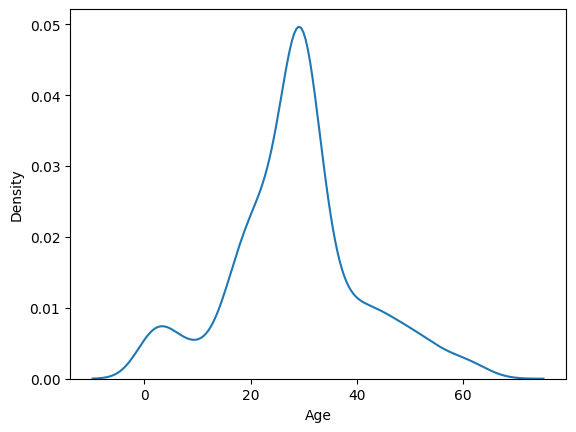

In [61]:
sns.kdeplot(data=x_train, x='Age')

In [62]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

ss.fit(x_train[['Age']])
x_train['Age'] = ss.transform(x_train[['Age']]).ravel()
x_test['Age'] = ss.transform(x_test[['Age']]).ravel()


In [63]:
x_train.sample(5)

,Age,SibSp,Parch,Fare,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
351,0.079731,0,0,35.0000,2.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
146,-0.124331,0,0,7.7958,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
734,-0.450981,0,0,13.0000,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
364,0.079731,1,0,15.5000,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
106,-0.614306,0,0,7.6500,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [64]:
round(x_train['Age'].mean(),5)

np.float64(-0.0)

In [65]:
round(x_train['Age'].std(),5)

1.00082

<Axes: xlabel='Age', ylabel='Density'>

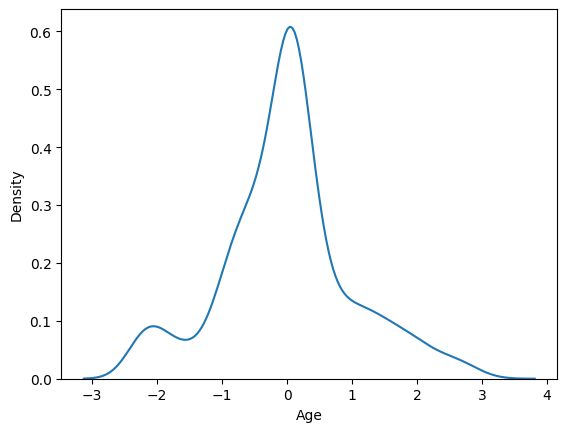

In [66]:
sns.kdeplot(data=x_train, x='Age')

# min max Scaling

<Axes: xlabel='Fare', ylabel='Density'>

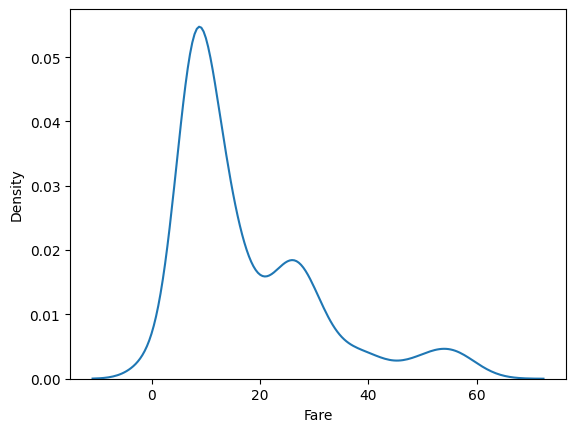

In [67]:
sns.kdeplot(data=x_train, x='Fare')

In [68]:
from sklearn.preprocessing import MinMaxScaler

mns = MinMaxScaler()

mns.fit(x_train[['Fare']])

x_train['Fare'] = mns.transform(x_train[['Fare']]).ravel()
x_test['Fare'] = mns.transform(x_test[['Fare']]).ravel()

In [69]:
x_train['Fare'].describe()

,Fare
count,612.000000
mean,0.283780
std,0.214178
min,0.000000
25%,0.128640
50%,0.205078
75%,0.423596
max,1.000000


<Axes: xlabel='Fare', ylabel='Density'>

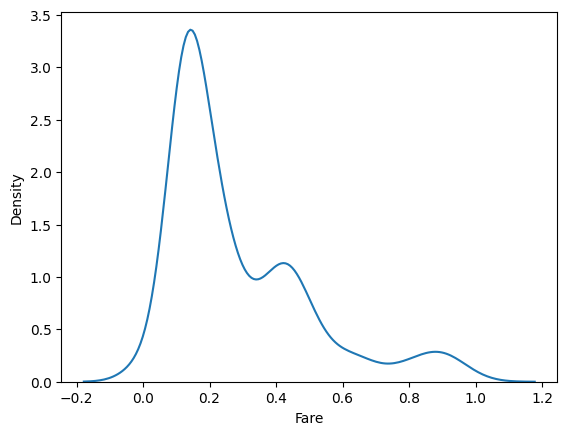

In [70]:
sns.kdeplot(data=x_train, x='Fare')

# column transformer:

In [87]:
from sklearn.impute import SimpleImputer

age_mean = x_train['Age'].mean()
age_median = x_train['Age'].median()

age_imputor = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputor.fit(x_train[['Age']])

x_train['Age'] = age_imputor.transform(x_train[['Age']]).ravel()

In [119]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [120]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2


In [121]:
X = df.drop(['Survived'], axis=1)
Y = df['Survived']

X['Family_size']  = X['SibSp'] + X['Parch'] + 1
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Family_size
0,third,male,22.0,1,0,7.2500,NaN,S,2
1,first,female,38.0,1,0,71.2833,C85,C,2
2,third,female,26.0,0,0,7.9250,NaN,S,1
3,first,female,35.0,1,0,53.1000,C123,S,2
4,third,male,35.0,0,0,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S,1
887,first,female,19.0,0,0,30.0000,B42,S,1
888,third,female,NaN,1,2,23.4500,NaN,S,4
889,first,male,26.0,0,0,30.0000,C148,C,1


In [122]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [123]:
imputer_transformer = ColumnTransformer(
    transformers =[
        ('age', SimpleImputer(missing_values=np.nan, strategy='mean'), ['Age']),
        ('emberked', SimpleImputer(missing_values=np.nan, strategy='most_frequent'), ['Embarked']),
        ('cabin', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True), ['Cabin'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False

)
imputer_transformer.set_output(transform='pandas')
imputer_transformer.fit(X_train)

X_train = imputer_transformer.transform(X_train)
X_test = imputer_transformer.transform(X_test)

In [124]:
X_train.isna().sum()

,0
Age,0
Embarked,0
Cabin,0
missingindicator_Cabin,0
Pclass,0
Sex,0
SibSp,0
Parch,0
Fare,0
Family_size,0


In [125]:
X_train.head()

,Age,Embarked,Cabin,missingindicator_Cabin,Pclass,Sex,SibSp,Parch,Fare,Family_size
331,45.5,S,C124,False,first,male,0,0,28.5000,1
733,23.0,S,Missing,True,second,male,0,0,13.0000,1
382,32.0,S,Missing,True,third,male,0,0,7.9250,1
704,26.0,S,Missing,True,third,male,1,0,7.8542,2
813,6.0,S,Missing,True,third,female,4,2,31.2750,7


In [129]:
X_train['Cabin_deck'] = x_train['Cabin'].astype(str).str[0]
X_test['Cabin_deck'] = x_test['Cabin'].astype(str).str[0]

In [130]:
X_train.head()

,Age,Embarked,Cabin,missingindicator_Cabin,Pclass,Sex,SibSp,Parch,Fare,Family_size,Cabin_deck
331,45.5,S,C124,False,first,male,0,0,28.5000,1,C
733,23.0,S,Missing,True,second,male,0,0,13.0000,1,n
382,32.0,S,Missing,True,third,male,0,0,7.9250,1,n
704,26.0,S,Missing,True,third,male,1,0,7.8542,2,n
813,6.0,S,Missing,True,third,female,4,2,31.2750,7,n


In [131]:
encoder_scaler = ColumnTransformer(
    transformers=[
        ('pclass', OrdinalEncoder(categories=[["third", "second", "first"]]), ['Pclass']),
        ('sex', OneHotEncoder(sparse_output=False, drop='first'), ['Sex', 'Embarked', 'Cabin_deck']),

        ('age', StandardScaler(), ['Age']),
        ('fare', MinMaxScaler(), ['Fare', 'Family_size'])
    ],

    remainder='passthrough',
    verbose_feature_names_out=False
)
encoder_scaler.set_output(transform='pandas')
encoder_scaler.fit(X_train)

X_train = encoder_scaler.transform(X_train)
X_test = encoder_scaler.transform(X_test)


In [132]:
X_train

,Pclass,Sex_male,Embarked_Q,Embarked_S,Cabin_deck_B,Cabin_deck_C,Cabin_deck_D,Cabin_deck_E,Cabin_deck_F,Cabin_deck_G,Cabin_deck_T,Cabin_deck_n,Age,Fare,Family_size,Cabin,missingindicator_Cabin,SibSp,Parch
331,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.232263e+00,0.055628,0.0,C124,False,0,0
733,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-5.004820e-01,0.025374,0.0,Missing,True,0,0
382,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.926161e-01,0.015469,0.0,Missing,True,0,0
704,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-2.694493e-01,0.015330,0.1,Missing,True,1,0
813,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.809667e+00,0.061045,0.6,Missing,True,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-6.545038e-01,0.014932,0.0,Missing,True,0,0
270,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.735977e-16,0.060508,0.0,Missing,True,0,0
860,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,8.857142e-01,0.027538,0.2,Missing,True,2,0
435,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.193580e+00,0.234224,0.3,B96 B98,False,1,2


In [134]:
X_train.drop(['Cabin', 'missingindicator_Cabin', 'SibSp', 'Parch'], axis=1, inplace=True)
X_test.drop(['Cabin', 'missingindicator_Cabin', 'SibSp', 'Parch'], axis=1, inplace=True)



Final Dataset for feed

In [135]:
X_train

,Pclass,Sex_male,Embarked_Q,Embarked_S,Cabin_deck_B,Cabin_deck_C,Cabin_deck_D,Cabin_deck_E,Cabin_deck_F,Cabin_deck_G,Cabin_deck_T,Cabin_deck_n,Age,Fare,Family_size
331,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.232263e+00,0.055628,0.0
733,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-5.004820e-01,0.025374,0.0
382,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.926161e-01,0.015469,0.0
704,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-2.694493e-01,0.015330,0.1
813,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.809667e+00,0.061045,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-6.545038e-01,0.014932,0.0
270,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.735977e-16,0.060508,0.0
860,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,8.857142e-01,0.027538,0.2
435,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.193580e+00,0.234224,0.3
